# Unsupervised learning

Examples of unsupervised learning:

1. Dimensionality reduction (Discussed in the previous chapter).
2. Clustering: grouping similar instances together into clusters. 
3. Anomaly detection: Learning what 'normal' data looks like so that the model can detect abnormal data.
4. Density estimation: estimating the probability density function (PDF) of the random process that generated the dataset. 

## Clustering

Clustering simply tries to assign similar clusters the same label without knowing the labels beforehand. 

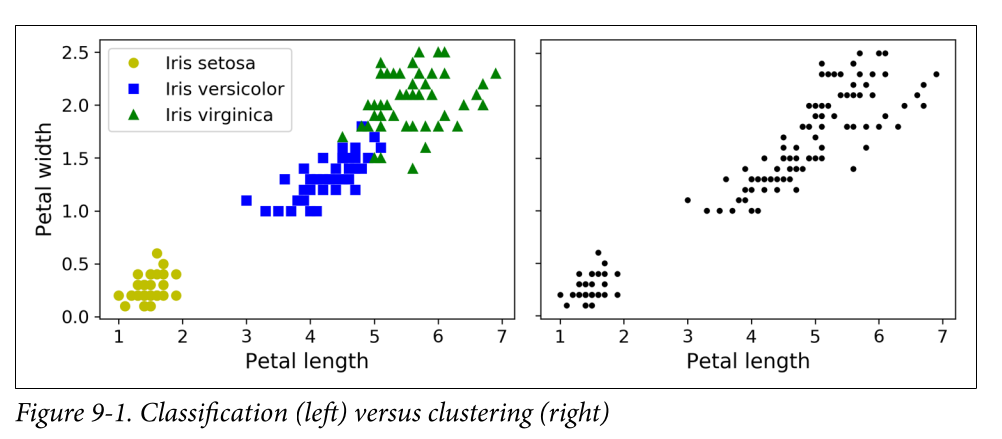

Clustering is used in a wide variety of applications, including:
1. Customer segmentation: clustering customers based on their purchases and their activity on a website.
2. Data analysis.
3. Dimensionality reduction: After clustering the data, it is possible to calculate the _affinity_ of each instance to each cluster. This results in a vector of affinities of size _k_, which is much lower-dimensional than the original feature space of the instances.
4. Anomaly detection (outlier detection): Any instance that has a low affinity to all clusters is likely to be an anomaly. 
5. Semi-supervised learning: If you have a few labels, you could perform clustering and propagate the labels to all the instances in the same cluster.
6. Search engines: Some search engines let you search for images that are similar to a reference image. 
7. Image segmentation: By clustering pixels according to their color, then replacing each pixel's color with the mean color of its cluster.  

## K-Means
K means is suitable for clustering datasets that look like the following:

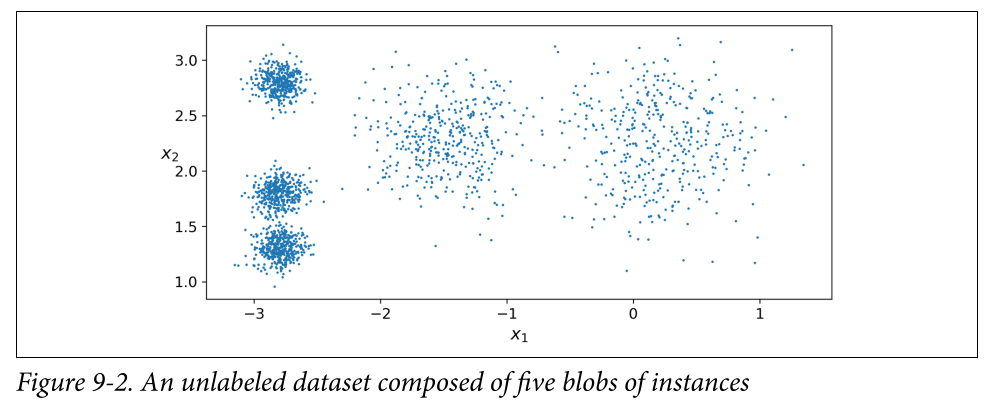

You can clearly see that there are 5 blobs of instances in the dataset, which means that it is possible to cluster this dataset into 5 clusters.

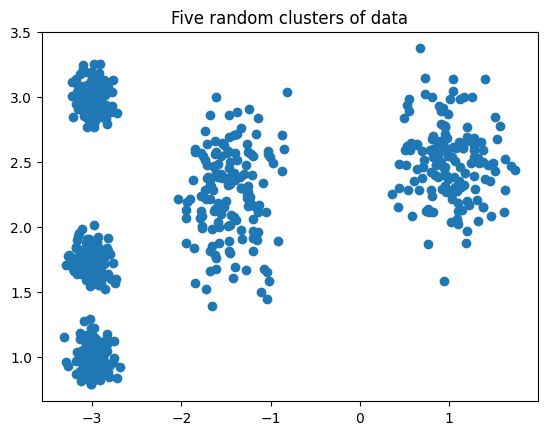

In [62]:
import numpy as np
from matplotlib import pyplot as plt
samples_per_cluster = 150
sigma = 0.1
#cluster 1
X1 = sigma * np.random.randn(samples_per_cluster) - 3
y1 = sigma * np.random.randn(samples_per_cluster) + 3

#cluster 2
X2 = sigma * np.random.randn(samples_per_cluster) - 3
y2 = sigma * np.random.randn(samples_per_cluster) + 1.75

#cluster 3
X3 = sigma * np.random.randn(samples_per_cluster) - 3
y3 = sigma * np.random.randn(samples_per_cluster) + 1

#cluster 4
X4 = 3 * sigma * np.random.randn(samples_per_cluster) - 1.5
y4 = 3 * sigma * np.random.randn(samples_per_cluster) + 2.25


#cluster 5
X5 = 3 * sigma * np.random.randn(samples_per_cluster) + 1
y5 = 3 * sigma * np.random.randn(samples_per_cluster) + 2.5

X = np.concatenate([X1, X2, X3, X4, X5])
y = np.concatenate([y1, y2, y3, y4, y5])
plt.scatter(X, y)
plt.title('Five random clusters of data')
plt.show()

In [63]:
from sklearn.cluster import KMeans
training_data = np.c_[X, y]
kmeans = KMeans(n_clusters = 5)
y_pred = kmeans.fit_predict(training_data)

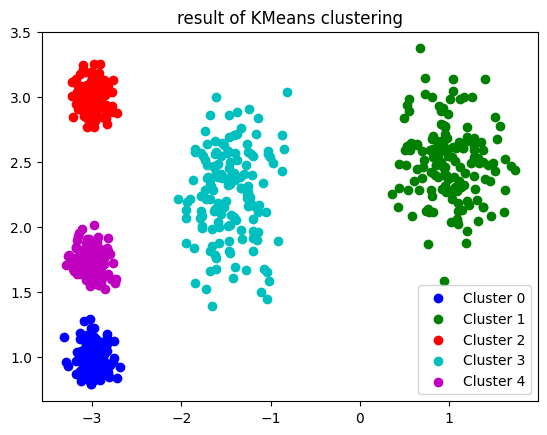

In [65]:
colors = [
    'b',
    'g',
    'r',
    'c',
    'm'
]

fig, axes = plt.subplots()
for i, color in enumerate(colors):
    axes.scatter(training_data[y_pred == i, 0], training_data[y_pred == i, 1], color = color, label = f'Cluster {i}')
axes.set_title('result of KMeans clustering')
axes.legend(loc = 'best')
plt.show()

You can use the _transform_ function to find the distance between the instance and each of the cluster centroids, which can be an efficient dimensionality reduction algorithm.

In [67]:
kmeans.transform(np.array([[0.1, 2.4]]))

array([[3.39605625, 0.91175746, 3.15587471, 1.56250494, 3.1613249 ]])

The above result shows that the distance between the input sample and the second cluster (0.91175746) is the lowest, which means that the instance belongs to that cluster.

KMeans works as follows:
1. Select random centroids to begin.
2. Label the instances with the same label as the centroid they are closest to.
3. Move the centroids toward the mean of the labeled instances.
4. Repeat steps 2 and 3 until the centroids stop moving. 

The initial position of the centroids can greatly affect the resulting model. If you are lucky, you can end up with a perfect model from the first try, but sometimes you don't. 

A solution to this problem is to run the KMeans algorithm multiple times and keep the best solution. This is the default behavior in scikit-learn as it run the KMeans algorithm 10 times and keeps the best solution.

the n_init parameter sets the number of the times the algorithm runs before it decides to keep the best solution.


In [72]:
#n_init sets the number of times the algorithm runs!
kmeans = KMeans(n_clusters = 5, n_init = 100)
kmeans.fit(np.expand_dims(X, -1))


KMeans(n_clusters=5, n_init=100)

The best solution is determined using the _inertia_, which is a metric that measures the average squared distance between each instance and its closest centroid. 

In [74]:
kmeans.inertia_

12.866424507980136

In [77]:
kmeans.score(np.expand_dims(X, -1))

-12.866424507980138

The score function returns a negative number because scikit-learn requires that the greater the number returned, the better the model is. 

There is a new version of KMeans called KMeans++, which improves the way the initial position for the centroids is chosen.

It works as follows:
1. Take the centroid chosen uniformly at random from the dataset.
2. Take a new centroid that is an instance chosen with a probability of: <br>$\frac{D(x^{(i)})^2}{\sum_{j = 1}^{m}D(x^{(j)})^2}$, where $D(x^{(i)})$ is the distance between the instance and the closest centroid that was already chosen. This probability ensures that instances farther away from already chosen centroids are much more likely to be selected as centroids. 
3. Repeat the previous step until all centroids have been chosen.  

This initialization method is the default that is used by scikit-learn!